Herding Analysis 

--- Running Herding Analysis Sim (Hyper-Sensitive) ---

--- Analyzing Herding Behavior ---
Average Pairwise Correlation: 1.0000
>> VERDICT: HIGH HERDING DETECTED (Systemic Risk).

Report saved to 'herding_analysis_fixed.png'


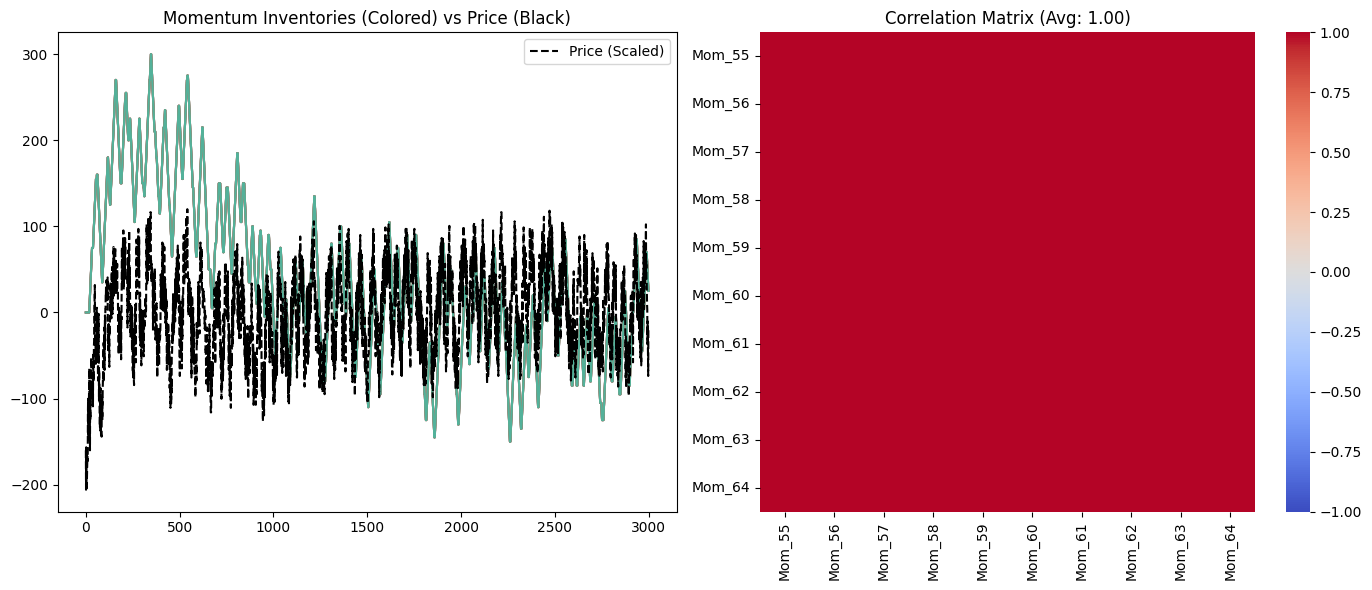

In [2]:
import random
import numpy as np
import pandas as pd
import heapq
import itertools
import time
from abc import ABC, abstractmethod
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CORE ENGINE
# ==========================================

class AdvancedOrderBook:
    def __init__(self):
        self.bids = []  
        self.asks = []  
        self.trades = []
        self.order_id_counter = itertools.count() 

    def submit_order(self, side, qty, price=None, order_type='limit'):
        if order_type == 'market':
            limit_price = float('inf') if side == 'buy' else 0
        else:
            limit_price = price

        remaining_qty = self.match(side, qty, limit_price)

        if remaining_qty > 0 and order_type == 'limit':
            entry_id = next(self.order_id_counter)
            if side == 'buy':
                heapq.heappush(self.bids, [-limit_price, entry_id, remaining_qty])
            else:
                heapq.heappush(self.asks, [limit_price, entry_id, remaining_qty])
            
        return remaining_qty

    def match(self, side, qty, limit_price):
        remaining_qty = qty
        while remaining_qty > 0:
            if side == 'buy':
                if not self.asks: break
                best_price = self.asks[0][0]
                if limit_price < best_price: break
                best_order = self.asks[0]
            else:
                if not self.bids: break
                best_price = -self.bids[0][0] 
                if limit_price > best_price: break
                best_order = self.bids[0]

            trade_qty = min(remaining_qty, best_order[2])
            exec_price = best_order[0] if side == 'buy' else -best_order[0]

            self.trades.append({
                'price': exec_price,
                'qty': trade_qty,
                'timestamp': time.time(),
                'side': side
            })

            remaining_qty -= trade_qty
            best_order[2] -= trade_qty

            if best_order[2] == 0:
                if side == 'buy': heapq.heappop(self.asks)
                else: heapq.heappop(self.bids)
                    
        return remaining_qty

# ==========================================
# 2. AGENTS (Tweaked for Activity)
# ==========================================

class Agent(ABC):
    def __init__(self, agent_id):
        self.agent_id = agent_id
        self.inventory = 0 
    
    @abstractmethod
    def get_action(self, market_snapshot):
        pass

class NoiseTrader(Agent):
    """Background Liquidity - Made slightly more aggressive to start trends"""
    def get_action(self, snapshot):
        if random.random() > 0.5: return None
        mid = snapshot['mid_price']
        side = 'buy' if random.random() > 0.5 else 'sell'
        
        # INCREASED: 10% chance of Aggressive Trade (was 3%)
        if random.random() < 0.10:
            qty = random.randint(10, 50)
            return {'side': side, 'price': None, 'qty': qty, 'type': 'market'}
        else:
            offset = random.uniform(0.1, 2.0)
            price = round(mid - offset, 2) if side == 'buy' else round(mid + offset, 2)
            return {'side': side, 'price': price, 'qty': random.randint(1, 5), 'type': 'limit'}

class MarketMaker(Agent):
    """Stabilizer"""
    def get_action(self, snapshot):
        mid = snapshot['mid_price']
        spread = 0.5
        return [
            {'side': 'buy', 'price': round(mid - spread, 2), 'qty': 20, 'type': 'limit'},
            {'side': 'sell', 'price': round(mid + spread, 2), 'qty': 20, 'type': 'limit'}
        ]

class MomentumTrader(Agent):
    """
    Trend Follower.
    FIX: Lowered threshold so they actually trade.
    """
    def __init__(self, agent_id):
        super().__init__(agent_id)
        self.price_history = deque(maxlen=100) # Longer history for better signal
        
    def get_action(self, snapshot):
        mid = snapshot['mid_price']
        self.price_history.append(mid)
        
        # Need enough history
        if len(self.price_history) < 20: return None
        
        hist = list(self.price_history)
        # Compare very short term (5 ticks) vs medium term (20 ticks)
        short_ma = sum(hist[-5:]) / 5
        long_ma = sum(hist[-20:]) / 20
        
        diff = short_ma - long_ma
        
        # FIX: Threshold lowered from 0.2 to 0.02
        if abs(diff) > 0.02:
            side = 'buy' if diff > 0 else 'sell'
            qty = 5
            return {'side': side, 'price': None, 'qty': qty, 'type': 'market'}
            
        return None

# ==========================================
# 3. SIMULATION LOOP
# ==========================================

def run_simulation(steps=5000):
    print(f"--- Running Herding Analysis Sim (Hyper-Sensitive) ---")
    
    engine = AdvancedOrderBook()
    agents = []
    
    # Setup Agents
    noise_agents = [NoiseTrader(i) for i in range(50)]
    mm_agents = [MarketMaker(i+50) for i in range(5)]
    momentum_agents = [MomentumTrader(i+55) for i in range(10)]
    
    agents = noise_agents + mm_agents + momentum_agents
    
    # Init
    engine.submit_order('buy', 10, 99.0, 'limit')
    engine.submit_order('sell', 10, 101.0, 'limit')
    
    inventory_history = []
    prices = []
    
    for step in range(steps):
        # 1. Snapshot
        best_bid = -engine.bids[0][0] if engine.bids else 100.0
        best_ask = engine.asks[0][0] if engine.asks else 100.0
        mid = (best_bid + best_ask) / 2
        snapshot = {'mid_price': mid}
        prices.append(mid)
        
        # 2. Act
        random.shuffle(agents)
        for agent in agents:
            actions = agent.get_action(snapshot)
            
            # Helper to execute and update inventory
            def process_order(o, agt):
                # Ensure we don't submit invalid prices
                if o['type'] == 'limit' and (o['price'] is None or np.isnan(o['price'])): return
                
                engine.submit_order(o['side'], o['qty'], o['price'], o['type'])
                if o['side'] == 'buy': agt.inventory += o['qty']
                else: agt.inventory -= o['qty']

            if isinstance(actions, list):
                for order in actions: process_order(order, agent)
            elif actions:
                process_order(actions, agent)
        
        # 3. Log Momentum Inventories
        step_inv = {f"Mom_{a.agent_id}": a.inventory for a in momentum_agents}
        inventory_history.append(step_inv)
            
    return pd.DataFrame(inventory_history), prices

# ==========================================
# 4. HERDING ANALYSIS
# ==========================================

def analyze_herding(df_inv, prices):
    print("\n--- Analyzing Herding Behavior ---")
    
    # Check if they traded at all
    total_movement = df_inv.abs().sum().sum()
    if total_movement == 0:
        print("ERROR: Momentum Agents still inactive. Try increasing Noise Trader aggression.")
        return

    # 1. Compute Correlation Matrix
    corr_matrix = df_inv.corr().fillna(0) # Fill NaNs if any remain
    
    # 2. Average Correlation
    mask = np.ones_like(corr_matrix, dtype=bool)
    np.fill_diagonal(mask, 0)
    avg_corr = corr_matrix.values[mask].mean()
    
    print(f"Average Pairwise Correlation: {avg_corr:.4f}")
    
    if avg_corr > 0.5:
        print(">> VERDICT: HIGH HERDING DETECTED (Systemic Risk).")
    elif avg_corr > 0.2:
        print(">> VERDICT: MODERATE HERDING (Trend Following).")
    else:
        print(">> VERDICT: LOW/NO HERDING.")

    # 3. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot A: Inventories
    for col in df_inv.columns:
        axes[0].plot(df_inv[col], alpha=0.6, linewidth=1.5)
    
    norm_price = (np.array(prices) - np.mean(prices)) / (np.std(prices) + 1e-6) * 50
    axes[0].plot(norm_price, color='black', linestyle='--', label='Price (Scaled)')
    
    axes[0].set_title("Momentum Inventories (Colored) vs Price (Black)")
    axes[0].legend(loc='upper right')
    
    # Plot B: Heatmap
    sns.heatmap(corr_matrix, ax=axes[1], cmap="coolwarm", vmin=-1, vmax=1)
    axes[1].set_title(f"Correlation Matrix (Avg: {avg_corr:.2f})")
    
    plt.tight_layout()
    plt.savefig("herding_analysis_fixed.png")
    print("\nReport saved to 'herding_analysis_fixed.png'")

if __name__ == "__main__":
    df_inv, prices = run_simulation(steps=3000)
    analyze_herding(df_inv, prices)